In [5]:
#1. Implement single neuron using function from scratch 
#CODE:
import numpy as np
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def single_neuron(inputs, weights, bias):
    summation = np.dot(inputs, weights) + bias
    output = sigmoid(summation)
    return output
inputs = np.array([1, 0, 1])
weights = np.array([0.6, -0.3, 0.8])
bias = 0.2
output = single_neuron(inputs, weights, bias)
print("Neuron Output:", output)



Neuron Output: 0.8320183851339245


In [6]:
#2. Implement the AND, OR logical gate using a single-layer perceptron. 
#CODE:
import numpy as n
def perceptron(x, weights, bias):
    y = np.dot(x, weights) + bias
    return 1 if y >= 0 else 0
inputs = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])
# AND Gate
weights_and = np.array([1,1])
bias_and = -1.5
print("AND Gate")
for x in inputs:
    print(x, perceptron(x, weights_and, bias_and))
# OR Gate
weights_or = np.array([1,1])
bias_or = -0.5
print("\nOR Gate")
for x in inputs:
    print(x, perceptron(x, weights_or, bias_or))


AND Gate
[0 0] 0
[0 1] 0
[1 0] 0
[1 1] 1

OR Gate
[0 0] 0
[0 1] 1
[1 0] 1
[1 1] 1


In [8]:
#3. Implement Single Layer Perceptron - Binary classification , Training and testing , Performance evaluation.(Breast Cancer Dataset)
#CODE:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = Perceptron(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [7]:
# 4. implement a Multilayer Perceptron (MLP) with a hidden layer to solve the XOR problem using a non-linear activation function. 

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 0])
model = Sequential([
    tf.keras.Input(shape=(2,)),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.fit(X, y, epochs=500, verbose=0)
pred = model.predict(X)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
[[0.4749751 ]
 [0.6955154 ]
 [0.4749615 ]
 [0.35696957]]


In [3]:
#5. Implement Multi-Layer Perceptron (MLP) - Classification using Iris/Breast Cancer Dataset, Hyperparameter tuning 
#CODE:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

parameters = {
    'hidden_layer_sizes': [(10,), (20,), (20,10)],
    'learning_rate_init': [0.001,0.01],
    'max_iter':[2000]
}
grid = GridSearchCV(MLPClassifier(), parameters, cv=3)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Accuracy:", grid.score(X_test, y_test))


Best Parameters: {'hidden_layer_sizes': (10,), 'learning_rate_init': 0.001, 'max_iter': 2000}
Accuracy: 1.0


In [9]:
#6. Implement Multilayer Perceptron (MLP) for handwritten digit recognition using the MNIST dataset. 
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0
model = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train, y_train, epochs=5)
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9290 - loss: 0.2411
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9684 - loss: 0.1023
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9779 - loss: 0.0710
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9833 - loss: 0.0542
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9859 - loss: 0.0436
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9776 - loss: 0.0740
Accuracy: 0.9775999784469604


In [11]:
#7. To design a feedforward neural network with multiple hidden layers and compare the performance of SGD and Adam optimizers. 

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adam
(X_train,y_train),(X_test,y_test)=mnist.load_data()
X_train=X_train/255.0
X_test=X_test/255.0
def create_model(optimizer):
    model=Sequential([
        tf.keras.Input(shape=(28, 28)),
        Flatten(),
        Dense(256,activation='relu'),
        Dense(128,activation='relu'),
        Dense(64,activation='relu'),
        Dense(10,activation='softmax')
    ])
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
model_sgd=create_model(SGD())
model_adam=create_model(Adam())
print("Training with SGD")
model_sgd.fit(X_train,y_train,epochs=5)
print("Training with Adam")
model_adam.fit(X_train,y_train,epochs=5)


Training with SGD
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8358 - loss: 0.5979
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9249 - loss: 0.2581
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9417 - loss: 0.2017
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9522 - loss: 0.1664
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9596 - loss: 0.1407
Training with Adam
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9387 - loss: 0.2089
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9711 - loss: 0.0928
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9800 - loss: 0.0646
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9848 - loss: 0.0483
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9877 - loss: 0.0388


In [13]:
#8. To implement a simple Autoencoder using TensorFlow/Keras for removing noise from images. 
#CODE:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype("float32")/255.
x_test=x_test.astype("float32")/255.
x_train=x_train.reshape((len(x_train),784))
x_test=x_test.reshape((len(x_test),784))
noise_factor=0.5
x_train_noisy=x_train+noise_factor*np.random.normal(size=x_train.shape)
x_test_noisy=x_test+noise_factor*np.random.normal(size=x_test.shape)
input_img=Input(shape=(784,))
encoded=Dense(64,activation='relu')(input_img)
decoded=Dense(784,activation='sigmoid')(encoded)
autoencoder=Model(input_img,decoded)
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)
autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=256
)
decoded_imgs=autoencoder.predict(x_test_noisy)


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2559
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1616
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1408
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1298
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1234
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [2]:
#9. To reduce high-dimensional image data into low-dimensional latent features using an Autoencoder. 
#CODE:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
(x_train,_),_=mnist.load_data()
x_train=x_train.reshape(len(x_train),784)/255.
input_img=Input(shape=(784,))
encoded=Dense(32,activation='relu')(input_img)
decoded=Dense(784,activation='sigmoid')(encoded)
autoencoder=Model(input_img,decoded)
encoder=Model(input_img,encoded)
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)
autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256
)
latent_features=encoder.predict(x_train)
print(latent_features.shape)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2788
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1693
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1437
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1287
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1181
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 866us/step
(60000, 32)


In [3]:
#10. To compress images using Autoencoder. 
#CODE:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
(x_train,_),_=mnist.load_data()
x_train=x_train.reshape(len(x_train),784)/255.
input_img=Input(shape=(784,))
encoded=Dense(16,activation='relu')(input_img)
decoded=Dense(784,activation='sigmoid')(encoded)
autoencoder=Model(input_img,decoded)
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)
autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256
)
compressed=autoencoder.predict(x_train)
print(compressed.shape)


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3093
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2001
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1728
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1584
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1499
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
(60000, 784)


In [5]:
#11. To implement a Variational Autoencoder for generating handwritten digit images.
#CODE:
import tensorflow as tf
from tensorflow.keras import layers
latent_dim = 2
encoder = tf.keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(latent_dim + latent_dim)
])
decoder = tf.keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(784, activation='sigmoid')
])
(x_train,_),_=tf.keras.datasets.mnist.load_data()
x_train=x_train.reshape(-1,784).astype("float32")/255.0
optimizer=tf.keras.optimizers.Adam()
for epoch in range(5):
    for batch in tf.data.Dataset.from_tensor_slices(x_train).batch(128):
        with tf.GradientTape() as tape:
            mean, logvar = tf.split(
                encoder(batch),
                num_or_size_splits=2,
                axis=1
            )
            eps=tf.random.normal(shape=mean.shape)
            z=mean+tf.exp(0.5*logvar)*eps
            reconstruction=decoder(z)
            recon_loss=tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(
                    batch,
                    reconstruction
                )
            )
            kl_loss=-0.5*tf.reduce_mean(
                1+logvar-tf.square(mean)-tf.exp(logvar)
            )
            loss=recon_loss+kl_loss
        grads=tape.gradient(
            loss,
            encoder.trainable_variables+decoder.trainable_variables
        )
        optimizer.apply_gradients(
            zip(
                grads,
                encoder.trainable_variables+decoder.trainable_variables
            )
        )
    print("Epoch", epoch+1, "Loss:", loss.numpy())

Epoch 1 Loss: 0.26259375
Epoch 2 Loss: 0.2602613
Epoch 3 Loss: 0.259872
Epoch 4 Loss: 0.25966746
Epoch 5 Loss: 0.25994864


Epoch 1 Loss: 0.26168305
Epoch 2 Loss: 0.2597382
Epoch 3 Loss: 0.25963244
Epoch 4 Loss: 0.25954625
Epoch 5 Loss: 0.25992516


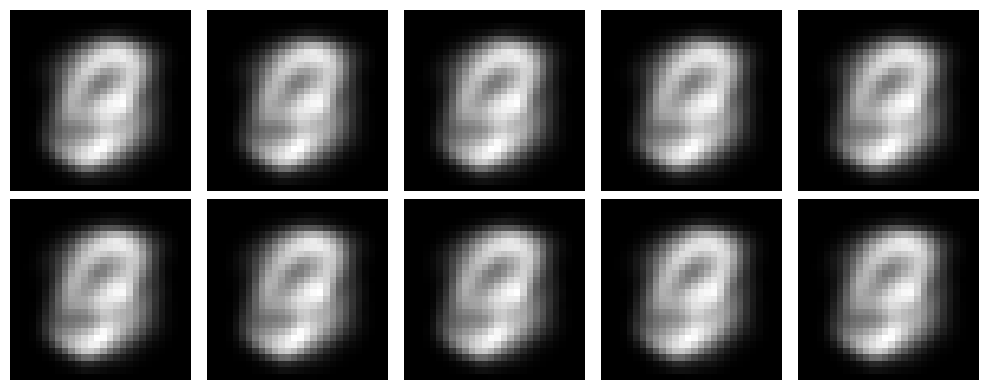

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers

# -----------------------------
# 1. Set latent dimension
# -----------------------------
latent_dim = 2

# -----------------------------
# 2. Encoder
# -----------------------------
encoder = tf.keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(latent_dim + latent_dim)
])

# -----------------------------
# 3. Decoder
# -----------------------------
decoder = tf.keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(784, activation='sigmoid')
])

# -----------------------------
# 4. Load MNIST dataset
# -----------------------------
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Convert 28x28 images into 784 values
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0

# -----------------------------
# 5. Optimizer
# -----------------------------
optimizer = tf.keras.optimizers.Adam()

# -----------------------------
# 6. Train VAE
# -----------------------------
for epoch in range(5):

    for batch in tf.data.Dataset.from_tensor_slices(x_train).batch(128):

        with tf.GradientTape() as tape:

            # Encoder output
            encoded = encoder(batch)

            # Split into mean and log variance
            mean, logvar = tf.split(
                encoded,
                num_or_size_splits=2,
                axis=1
            )

            # Reparameterization trick
            eps = tf.random.normal(shape=mean.shape)

            z = mean + tf.exp(0.5 * logvar) * eps

            # Decode latent vector
            reconstruction = decoder(z)

            # Reconstruction loss
            recon_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(
                    batch,
                    reconstruction
                )
            )

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                1 + logvar
                - tf.square(mean)
                - tf.exp(logvar)
            )

            # Total VAE loss
            loss = recon_loss + kl_loss

        # Calculate gradients
        grads = tape.gradient(
            loss,
            encoder.trainable_variables +
            decoder.trainable_variables
        )

        # Update weights
        optimizer.apply_gradients(
            zip(
                grads,
                encoder.trainable_variables +
                decoder.trainable_variables
            )
        )

    print("Epoch", epoch + 1, "Loss:", loss.numpy())


# -----------------------------
# 7. Generate new images
# -----------------------------

# Generate 10 random points in latent space
z = tf.random.normal(shape=(10, latent_dim))

# Decode them into images
generated_images = decoder(z)

# Convert 784 pixels back to 28x28
generated_images = generated_images.numpy().reshape(10, 28, 28)

# -----------------------------
# 8. Display generated images
# -----------------------------

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(generated_images[i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()